# Supervised Classification (Model Comparison)
This notebook demonstrates data preprocessing, train/test split, cross-validation, and comparison of two algorithms.
We compute: Accuracy, Precision, Recall, F1, and ROC-AUC.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)


## 1) Load data
Using a small supervised binary classification dataset (Breast Cancer).

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print('X shape:', X.shape)
print('y distribution:', np.bincount(y))
X.head()

X shape: (569, 30)
y distribution: [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2) Preprocessing + Train/Test split
- Features are standardized for Logistic Regression.
- Random Forest is tree-based and generally doesn't require scaling, but we still keep a consistent pipeline structure for comparison.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (455, 30) Test size: (114, 30)


## 3) Define algorithms
We compare:
1. Logistic Regression
2. Random Forest


In [4]:
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=5000, solver='lbfgs'))
])

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1))
])

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
}

## 4) Evaluation helper
We compute metrics on the held-out test set and ROC-AUC using predicted probabilities.

In [5]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, threshold=0.5):
    model.fit(X_train, y_train)

    # Probabilities for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        raise ValueError('Model must support predict_proba for ROC-AUC')

    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }
    return metrics, y_pred, y_prob, model

## 5) Cross-validation (optional view)
We also produce cross-validated predictions using StratifiedKFold.
(This can help understand stability of performance.)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    # cross_val_predict for class probabilities
    y_prob_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    y_pred_cv = (y_prob_cv >= 0.5).astype(int)
    cv_results[name] = {
        'accuracy': accuracy_score(y, y_pred_cv),
        'precision': precision_score(y, y_pred_cv, zero_division=0),
        'recall': recall_score(y, y_pred_cv, zero_division=0),
        'f1': f1_score(y, y_pred_cv, zero_division=0),
        'roc_auc': roc_auc_score(y, y_prob_cv),
    }

pd.DataFrame(cv_results).T

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.973638,0.967213,0.991597,0.979253,0.994675
Random Forest,0.952548,0.958333,0.966387,0.962343,0.988353


## 6) Train on training set + evaluate on test set


In [7]:
test_metrics = {}
best_model_name = None
best_roc_auc = -np.inf

for name, model in models.items():
    metrics, y_pred, y_prob, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    test_metrics[name] = metrics
    print(f'[{name}]', metrics)
    if metrics['roc_auc'] > best_roc_auc:
        best_roc_auc = metrics['roc_auc']
        best_model_name = name

results_df = pd.DataFrame(test_metrics).T
results_df.sort_values('roc_auc', ascending=False)

[Logistic Regression] {'accuracy': 0.9824561403508771, 'precision': 0.9861111111111112, 'recall': 0.9861111111111112, 'f1': 0.9861111111111112, 'roc_auc': 0.9953703703703703}


[Random Forest] {'accuracy': 0.956140350877193, 'precision': 0.958904109589041, 'recall': 0.9722222222222222, 'f1': 0.9655172413793104, 'roc_auc': 0.9932208994708995}


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
Random Forest,0.956140,0.958904,0.972222,0.965517,0.993221


## 7) Plots for each model


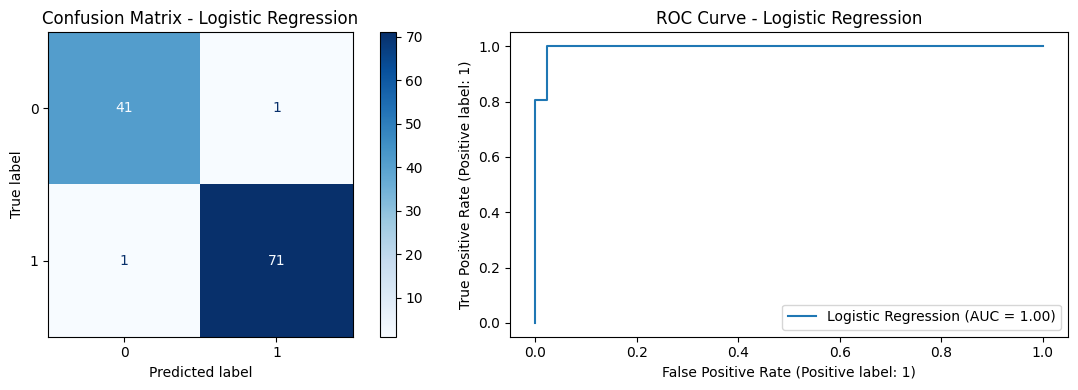

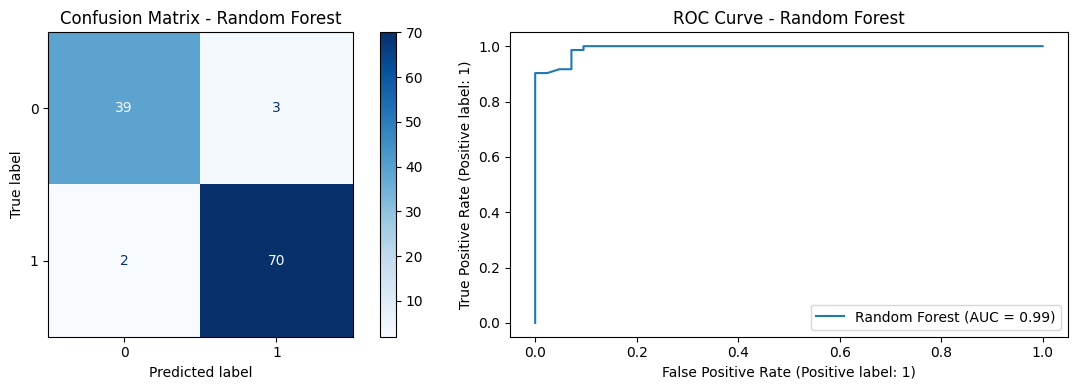

In [8]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():
    metrics, y_pred, y_prob, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0], values_format='d', cmap='Blues')
    axes[0].set_title(f'Confusion Matrix - {name}')

    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=name)
    axes[1].set_title(f'ROC Curve - {name}')

    plt.tight_layout()
    plt.savefig(f"{name.replace(' ', '_').lower()}_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()

## 8) Feature importance (Random Forest)
Random Forest provides feature importances.

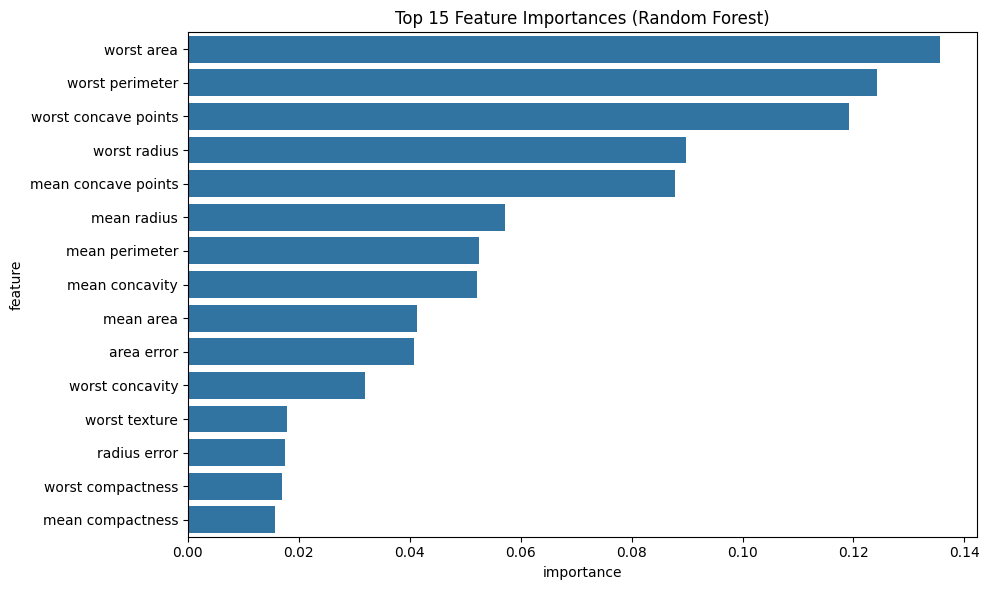

In [9]:
rf_fitted = models['Random Forest'].fit(X_train, y_train)
rf_clf = rf_fitted.named_steps['clf']

importances = rf_clf.feature_importances_
imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x='importance', y='feature', orient='h')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary
Best model on the test set by ROC-AUC is: **Logistic Regression**.

It achieved a test ROC-AUC of **0.9954** and an accuracy of **98.25%**, compared to Random Forest's test ROC-AUC of **0.9932** and accuracy of **95.61%**.